# Diabetic Readmission Prediction, Replication and Extension of Strack et al. (2014)

This notebook replicates and extends ["Impact of HbA1c Measurement on Hospital Readmission Rates"](https://doi.org/10.1155/2014/781670) (Strack et al., 2014), using the same Diabetes 130-US Hospitals dataset (101,766 encounters, 1999–2008).

**Goal:** the original paper used logistic regression purely for statistical inference (which factors are associated with readmission), it reports no predictive accuracy. This project builds an actual predictive model (30-day readmission risk), while deliberately testing one of the paper's own methodological choices against an alternative approach.

**What this notebook covers, in order:**
1. Data cleaning, following the paper's inclusion logic
2. A deliberate deviation from the paper's design (repeat-visit handling) and why
3. A baseline model, followed by a real bug I found and fixed mid-project
4. A direct empirical test of my approach against the paper's original method
5. Model explainability (SHAP), and a replication of the paper's core clinical finding

## Data Loading and Initial Cleaning

The raw dataset has 101,766 encounters and 50 columns. Before any modeling can happen, several columns need attention because of missing data, and the diagnosis codes need to be grouped into something usable.

The steps below follow the same logic the original paper used for handling missing values, but the actual cleaning decisions are made independently here rather than copied from their methodology.

In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/diabetic_data.csv')

print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Handling missing values

This dataset uses `'?'` as a placeholder for missing data rather than a true null, so the first step is converting those to proper NaN values so pandas can actually recognize them as missing.

Three columns stood out with heavy missingness: `weight` (about 97 percent missing), `payer_code` (about 40 percent missing), and `medical_specialty` (about 47 percent missing). The decisions on each are made in the next cell, but the reasoning is:

- `weight`: dropped entirely. At 97 percent missing there's essentially no usable signal left, and imputing it would mostly be guessing
- `payer_code`: dropped. Insurance type wasn't judged relevant to a patient's clinical readmission risk, and imputing 40 percent of a column that's tangential to the outcome isn't worth the risk of introducing noise
- `medical_specialty`: kept, with missing values filled as an explicit `"Missing"` category rather than dropped or imputed. Unlike weight or payer code, which specialty admitted a patient is plausibly related to case complexity, and "unknown specialty" might itself be informative rather than just noise

In [3]:
import numpy as np

df = df.replace('?', np.nan)

df.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
patient_nbr              0
dtype: int64

In [4]:
# Drop columns with unusable amounts of missing data
df = df.drop(columns=['weight', 'payer_code'])

# Fill missing values with an explicit "Missing" category
df['medical_specialty'] = df['medical_specialty'].fillna('Missing')
df['race'] = df['race'].fillna('Missing')

# Confirm the changes
print(df.shape)
df.isnull().sum().sort_values(ascending=False).head(10)

(101766, 48)


max_glu_serum        96420
A1Cresult            84748
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
race                     0
patient_nbr              0
time_in_hospital         0
medical_specialty        0
dtype: int64

### Defining the target variable

The original `readmitted` column has three values: `<30` (readmitted within 30 days), `>30` (readmitted after 30 days), and `NO` (no readmission on record). 

Following the same 30-day window the paper uses (a threshold commonly tied to funding agency definitions of early readmission), this gets collapsed into a binary target: `1` if a patient was readmitted within 30 days, `0` otherwise. That means both "readmitted after 30 days" and "never readmitted" get grouped together as the negative class, since the clinical and financial concern here is specifically early readmission.

Worth noting upfront: this creates a class imbalance problem, which shows up in the next cell and has to be accounted for later at the modeling stage.

In [5]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [5]:
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

df['readmitted_binary'].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [6]:
imbalance_ratio = df['readmitted_binary'].value_counts(normalize=True)
imbalance_ratio

readmitted_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64

### Grouping diagnosis codes

The dataset records up to three diagnoses per encounter (`diag_1`, `diag_2`, `diag_3`), each coded using ICD-9, with 700 to 900+ distinct codes per column. That's far too granular to use directly as categorical features without either exploding the dimensionality or badly overfitting on rare codes.

The paper solves this by grouping ICD-9 codes into broad clinical categories (circulatory, respiratory, digestive, diabetes, injury, and so on), based on standard ICD-9 chapter ranges. The same grouping logic is replicated here, coded as a function so it can be applied consistently across all three diagnosis columns.

This grouping will get checked against the paper's own published percentages later, as a sanity check that the replication was done correctly.

In [7]:
df['diag_1'].unique()[:20]

<StringArray>
['250.83',    '276',    '648',      '8',    '197',    '414',    '428',
    '398',    '434',  '250.7',    '157',    '518',    '999',    '410',
    '682',    '402',    '737',    '572',    'V57',    '189']
Length: 20, dtype: str

In [8]:
def map_diagnosis(code):
    # Handle missing values first
    if pd.isnull(code):
        return 'Missing'
    
    # Handle V-codes and E-codes (not numeric, so treat separately)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    
    # Convert to a number so we can check ranges
    # We only care about the part before the decimal point
    code_num = float(code)
    
    if (390 <= code_num <= 459) or code_num == 785:
        return 'Circulatory'
    elif (460 <= code_num <= 519) or code_num == 786:
        return 'Respiratory'
    elif (520 <= code_num <= 579) or code_num == 787:
        return 'Digestive'
    elif 250 <= code_num < 251:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif (580 <= code_num <= 629) or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# Apply this function to all three diagnosis columns
df['diag_1_group'] = df['diag_1'].apply(map_diagnosis)
df['diag_2_group'] = df['diag_2'].apply(map_diagnosis)
df['diag_3_group'] = df['diag_3'].apply(map_diagnosis)

df['diag_1_group'].value_counts()

diag_1_group
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Missing               21
Name: count, dtype: int64

In [9]:
print(df['diag_2_group'].value_counts())
print(df['diag_3_group'].value_counts())

diag_2_group
Circulatory        31881
Other              26553
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Musculoskeletal     1764
Missing              358
Name: count, dtype: int64
diag_3_group
Circulatory        30306
Other              29195
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Missing             1423
Name: count, dtype: int64


### Sanity check against the paper's published percentages

Comparing the `diag_1_group` distribution here against the paper's Table 2 (which reports percentages from their own 69,984-encounter final dataset) is a useful check that the grouping logic was implemented correctly, since it's easy to get an off-by-one error on ICD-9 range boundaries and not notice.

| Category | This notebook | Paper (Table 2) |
|---|---|---|
| Circulatory | 29.9% | 30.6% |
| Respiratory | 14.2% | 13.6% |
| Digestive | 9.3% | 9.3% |
| Diabetes | 8.6% | 8.2% |
| Injury | 6.9% | 6.7% |
| Musculoskeletal | 4.9% | 5.8% |
| Genitourinary | 5.0% | 4.9% |
| Neoplasms | 3.4% | 3.6% |

These numbers are close enough (within about 1 percentage point on most categories) to confirm the grouping logic matches the paper's approach, given that this comparison is being run on the full 101,766-row dataset before the death/hospice exclusion and other filtering the paper also applies, which accounts for the small remaining differences.

## Early Exploratory Analysis

Before making any further cleaning decisions, it's worth looking directly at how the target variable relates to a handful of key variables. This isn't the final analysis, that comes later with the actual model and SHAP, but a quick look here helps confirm the data behaves the way the paper describes and flags anything unexpected early.

A few things to check:
- Does HbA1c testing show any raw association with readmission, before adjusting for anything (this is the paper's central question)
- How does readmission rate vary by age
- How does it vary by primary diagnosis group
- What do the core numeric features (time in hospital, number of medications, prior visit counts) look like, and do they differ between readmitted and non-readmitted patients

In [10]:
df.groupby('A1Cresult', dropna=False)['readmitted_binary'].agg(['mean', 'count'])

,mean,count
A1Cresult,,
>7,0.100472,3812
>8,0.098710,8216
Norm,0.096593,4990
NaN,0.114233,84748


In [11]:
df.groupby('age')['readmitted_binary'].agg(['mean', 'count']).sort_index()

,mean,count
age,,
[0-10),0.018634,161
[10-20),0.057887,691
[20-30),0.142426,1657
[30-40),0.112318,3775
[40-50),0.106040,9685
[50-60),0.096662,17256
[60-70),0.111284,22483
[70-80),0.117731,26068
[80-90),0.120835,17197


In [12]:
df.groupby('diag_1_group')['readmitted_binary'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
diag_1_group,,
Missing,0.238095,21
Diabetes,0.129839,8757
Injury,0.122455,6974
Other,0.114792,18172
Circulatory,0.114499,30437
Genitourinary,0.108462,5117
Digestive,0.107124,9475
Neoplasms,0.100786,3433
Respiratory,0.097275,14423


In [13]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                 'num_medications', 'number_outpatient', 'number_emergency', 
                 'number_inpatient', 'number_diagnoses']

df[numeric_cols].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [14]:
df.groupby('readmitted_binary')[['number_inpatient', 'number_emergency', 'number_outpatient']].mean()

,number_inpatient,number_emergency,number_outpatient
readmitted_binary,,,
0,0.561648,0.177803,0.360871
1,1.224003,0.357313,0.436911


In [15]:
df.groupby('readmitted_binary')['num_medications'].mean()

readmitted_binary
0    15.911137
1    16.903143
Name: num_medications, dtype: float64

In [16]:
print(df.groupby('change')['readmitted_binary'].agg(['mean', 'count']))
print()
print(df.groupby('diabetesMed')['readmitted_binary'].agg(['mean', 'count']))

            mean  count
change                 
Ch      0.118228  47011
No      0.105908  54755

                 mean  count
diabetesMed                 
No           0.095971  23403
Yes          0.116267  78363


## Removing Death and Hospice Discharges

One more structural cleaning step is needed before the dataset is ready to model: patients who died during the encounter or were discharged to hospice need to be removed.

The reasoning is straightforward. The target variable is 30-day readmission, and a patient who died or was discharged to hospice cannot be readmitted in any meaningful sense. Leaving these encounters in would quietly bias the target, since they'd all effectively count as "not readmitted" for reasons that have nothing to do with the quality of their diabetes care.

This follows the same exclusion the paper applies. The relevant discharge disposition codes for death and hospice are identified below, and those encounters are dropped.

In [17]:
df['discharge_disposition_id'].value_counts().head(15)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
Name: count, dtype: int64

In [18]:
death_hospice_codes = [11, 13, 14, 19, 20, 21]

df['discharge_disposition_id'].isin(death_hospice_codes).sum()

np.int64(2423)

In [19]:
print(f"Before: {df.shape}")

df = df[~df['discharge_disposition_id'].isin(death_hospice_codes)]

print(f"After: {df.shape}")

Before: (101766, 52)
After: (99343, 52)


## Checking for Repeat Patient Visits

The dataset can contain multiple encounters from the same patient, which matters for two reasons. First, statistically, repeated observations from the same patient aren't independent, which is an assumption of most standard modeling approaches. Second, and more importantly for prediction, if a model saw one visit from a patient in training and a different visit from the same patient in test, it could partly "cheat" by learning patient-specific patterns rather than generalizable ones. That would inflate performance in a way that wouldn't hold up on genuinely new patients.

The first step is just quantifying how big this problem actually is before deciding how to handle it.

In [20]:
print(f"Total rows: {len(df)}")
print(f"Unique patients: {df['patient_nbr'].nunique()}")
print(f"Rows that are repeat visits: {len(df) - df['patient_nbr'].nunique()}")

Total rows: 99343
Unique patients: 69990
Rows that are repeat visits: 29353


## Note on Repeat Patient Visits

This dataset contains 99,343 encounters from 69,990 unique patients, meaning 29,353 rows (about 30 percent) are repeat visits from patients already represented elsewhere in the data.

The original paper (Strack et al., 2014) handled this by keeping only each patient's first encounter, reducing their dataset to one row per patient. That approach solves the statistical dependence problem cleanly, but it also throws away real information, particularly for patients whose later visits are the ones that actually ended in readmission.

This project takes a different approach: keep every encounter, and handle the dependence problem at the modeling stage instead, using GroupKFold cross-validation. GroupKFold ensures every visit from a single patient stays together in either the training split or the test split, never split across both. That prevents the kind of leakage described above while still letting the model learn from the full dataset rather than a reduced one.

This is a deliberate deviation from the paper's method, not just a different preference. The next section checks whether repeat patients actually carry a meaningful signal worth keeping, and later in the notebook, this approach gets tested directly against the paper's original method on the same model, to see whether it was actually worth it.

In [21]:
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
               'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
               'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
               'miglitol', 'troglitazone', 'tolazamide', 'examide', 
               'citoglipton', 'insulin', 'glyburide-metformin', 
               'glipizide-metformin', 'glimepiride-pioglitazone', 
               'metformin-rosiglitazone', 'metformin-pioglitazone']

for col in med_columns:
    print(df[col].value_counts())
    print()

metformin
No        79499
Steady    18207
Up         1063
Down        574
Name: count, dtype: int64

repaglinide
No        97825
Steady     1368
Up          107
Down         43
Name: count, dtype: int64

nateglinide
No        98654
Steady      654
Up           24
Down         11
Name: count, dtype: int64

chlorpropamide
No        99258
Steady       78
Up            6
Down          1
Name: count, dtype: int64

glimepiride
No        94221
Steady     4609
Up          322
Down        191
Name: count, dtype: int64

acetohexamide
No        99342
Steady        1
Name: count, dtype: int64

glipizide
No        86812
Steady    11219
Up          764
Down        548
Name: count, dtype: int64

glyburide
No        88820
Steady     9162
Up          801
Down        560
Name: count, dtype: int64

tolbutamide
No        99322
Steady       21
Name: count, dtype: int64

pioglitazone
No        92088
Steady     6908
Up          230
Down        117
Name: count, dtype: int64

rosiglitazone
No        93039
Stea

In [22]:
# For patients with more than one visit, check if being readmitted once 
# is associated with being readmitted again

repeat_patients = df[df.duplicated('patient_nbr', keep=False)]

print(f"Encounters from patients with 2+ visits: {len(repeat_patients)}")

# For each patient, calculate their personal readmission rate
patient_readmit_rate = repeat_patients.groupby('patient_nbr')['readmitted_binary'].mean()

print(patient_readmit_rate.describe())

Encounters from patients with 2+ visits: 45694
count    16341.000000
mean         0.176333
std          0.240621
min          0.000000
25%          0.000000
50%          0.000000
75%          0.333333
max          1.000000
Name: readmitted_binary, dtype: float64


### Interpreting the repeat-patient readmission rates

Among the 16,341 patients with two or more visits, the personal readmission rate varies widely rather than clustering around a single average. The median is 0 (over half of repeat patients were never readmitted early across any of their visits), but the 75th percentile is 0.33, meaning a meaningful chunk of patients were readmitted in roughly a third or more of their encounters.

That spread is the key finding here. If readmission were essentially random noise, personal readmission rates across repeat patients would cluster tightly around the overall base rate (about 11 percent) regardless of how many visits a patient had. Instead there's real dispersion, some patients are consistently low risk, others are consistently high risk, which suggests there's genuine patient-level signal in the data beyond what any single encounter captures.

This is the evidence behind the decision to keep repeat visits rather than follow the paper's first-encounter-only approach. Discarding those extra rows would mean discarding real signal, not just redundant noise.

## Consolidating Medication Features

The dataset includes 23 separate columns, one for each diabetes medication, each recording whether the dose went up, down, stayed steady, or wasn't prescribed at all. Looking at the value counts for each of these columns individually shows that most of them are extremely sparse, a handful of medications like metformin and insulin are prescribed often, but many others (examide, citoglipton, troglitazone, and several combination drugs) are barely used at all, some with only a handful of non-"No" values across the entire dataset.

Keeping 23 mostly-empty columns as separate features would add dimensionality without adding much real signal, and the model would struggle to learn anything reliable from medications prescribed to only a handful of patients. The approach here is to:

1. Drop the medications with negligible variance entirely
2. Consolidate the remaining medications into two summary features: how many diabetes medications a patient is on, and how many had a dosage change during the encounter
3. Keep insulin as its own separate feature rather than folding it into the summary, since insulin is clinically distinct from the oral medications, it's the primary tool for acute glycemic control during a hospital stay, whereas the oral medications are more about long-term management

In [23]:
cols_to_drop = ['examide', 'citoglipton', 'acetohexamide', 'tolbutamide', 
                 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone',
                 'metformin-rosiglitazone', 'metformin-pioglitazone']

df = df.drop(columns=cols_to_drop)

print(f"Shape after dropping low-variance medication columns: {df.shape}")

Shape after dropping low-variance medication columns: (99343, 43)


In [24]:
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
               'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 
               'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 
               'insulin', 'glyburide-metformin']

# Count how many of these 14 drugs the patient is actually on (i.e. not "No")
df['num_diabetes_meds'] = (df[med_columns] != 'No').sum(axis=1)

# Count how many medications had a dosage change (Up or Down) this encounter
df['num_med_dosage_changes'] = df[med_columns].isin(['Up', 'Down']).sum(axis=1)

df[['num_diabetes_meds', 'num_med_dosage_changes']].describe()

,num_diabetes_meds,num_med_dosage_changes
count,99343.000000,99343.000000
mean,1.186948,0.287368
std,0.922322,0.487861
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,2.000000,1.000000
max,6.000000,4.000000


In [25]:
# Keep insulin separate from the other 13 medications as a domain-informed decision:
# insulin is the primary medication for acute glycemic control in hospital settings,
# unlike oral medications which are more relevant to long-term management.

insulin_col = df['insulin'].copy()

other_med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
                       'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 
                       'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 
                       'glyburide-metformin']

df['num_diabetes_meds'] = (df[other_med_columns] != 'No').sum(axis=1)
df['num_med_dosage_changes'] = df[other_med_columns].isin(['Up', 'Down']).sum(axis=1)

df = df.drop(columns=other_med_columns)

df['insulin'] = insulin_col

print(f"Shape: {df.shape}")
df[['num_diabetes_meds', 'num_med_dosage_changes', 'insulin']].head()

Shape: (99343, 32)


,num_diabetes_meds,num_med_dosage_changes,insulin
0,0,0,No
1,0,0,Up
2,1,0,No
3,0,0,Up
4,1,0,Steady


In [26]:
print(df.shape)


(99343, 32)


In [27]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
insulin                       str
change                        str
diabetesMed                   str
readmitted                    str
readmitted_binary           int64
diag_1_group                  str
diag_2_group                  str
diag_3_group  

## Encoding Remaining Features

A few more columns need converting into a form a model can actually use.

- `diabetesMed` and `change`: simple yes/no columns, mapped directly to 1 and 0
- `age`: currently stored as string brackets like `[70-80)`. Rather than one-hot encoding ten separate age bands, the lower bound of each bracket is extracted as a number, keeping age as a single ordinal feature. This preserves the natural ordering (a 70 year old is closer in risk profile to an 80 year old than to a 10 year old), which one-hot encoding would throw away
- `max_glu_serum`, `A1Cresult`, and `insulin`: these are ordinal by nature (none, normal, moderately high, high, and so on), so they're mapped to numeric scales rather than one-hot encoded, for the same reason as age, preserving order rather than treating each level as an unrelated category
- `medical_specialty`: reduced from 84 distinct specialties down to the top 10 most common, with everything else grouped into "Other." This avoids one-hot encoding dozens of specialties that only appear a handful of times each, the same overfitting concern as the diagnosis codes earlier

In [28]:
df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})
df['change'] = df['change'].map({'Ch': 1, 'No': 0})

df[['diabetesMed', 'change']].head()

,diabetesMed,change
0,0,0
1,1,1
2,1,0
3,1,1
4,1,1


In [29]:
# Age: extract the lower bound of each bracket as a number
df['age'] = df['age'].apply(lambda x: int(x[1:3].replace('-', '')))

df['age'].value_counts().sort_index()

age
0       160
10      690
20     1649
30     3764
40     9607
50    17060
60    22059
70    25331
80    16434
90     2589
Name: count, dtype: int64

In [30]:
glucose_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
df['max_glu_serum'] = df['max_glu_serum'].map(glucose_map)

a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
df['A1Cresult'] = df['A1Cresult'].map(a1c_map)

insulin_map = {'No': 0, 'Down': 1, 'Steady': 2, 'Up': 3}
df['insulin'] = df['insulin'].map(insulin_map)

df[['max_glu_serum', 'A1Cresult', 'insulin']].isnull().sum()

max_glu_serum    94191
A1Cresult        82509
insulin              0
dtype: int64

In [31]:
df['max_glu_serum'] = df['max_glu_serum'].fillna(0)
df['A1Cresult'] = df['A1Cresult'].fillna(0)

df[['max_glu_serum', 'A1Cresult', 'insulin']].isnull().sum()

max_glu_serum    0
A1Cresult        0
insulin          0
dtype: int64

In [32]:
print(df['max_glu_serum'].value_counts().sort_index())
print()
print(df['A1Cresult'].value_counts().sort_index())
print()
print(df['insulin'].value_counts().sort_index())

max_glu_serum
0.0    94191
1.0     2545
2.0     1419
3.0     1188
Name: count, dtype: int64

A1Cresult
0.0    82509
1.0     4922
2.0     3775
3.0     8137
Name: count, dtype: int64

insulin
0    46379
1    11908
2    30069
3    10987
Name: count, dtype: int64


In [33]:
df['medical_specialty'].value_counts().head(15)

medical_specialty
Missing                            48616
InternalMedicine                   14237
Emergency/Trauma                    7419
Family/GeneralPractice              7252
Cardiology                          5279
Surgery-General                     3059
Nephrology                          1539
Orthopedics                         1392
Orthopedics-Reconstructive          1230
Radiologist                         1121
Pulmonology                          854
Psychiatry                           853
Urology                              682
ObstetricsandGynecology              669
Surgery-Cardiovascular/Thoracic      642
Name: count, dtype: int64

In [34]:
top_specialties = df['medical_specialty'].value_counts().head(10).index

df['medical_specialty_grouped'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

df['medical_specialty_grouped'].value_counts()

medical_specialty_grouped
Missing                       48616
InternalMedicine              14237
Other                          8199
Emergency/Trauma               7419
Family/GeneralPractice         7252
Cardiology                     5279
Surgery-General                3059
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Radiologist                    1121
Name: count, dtype: int64

## Final Encoding and Saving the Cleaned Dataset

With the remaining categorical columns (race, gender, medical specialty group, and the three diagnosis groups) one-hot encoded, the dataset is close to model-ready. A few identifier and now-redundant columns get dropped as well, since `encounter_id` carries no predictive information, and the raw `diag_1`/`diag_2`/`diag_3` and `medical_specialty` columns are no longer needed once their grouped versions exist.

The cleaned dataset gets saved to `data/processed/diabetic_data_cleaned.csv` at this point, so the modeling work that follows doesn't depend on rerunning the full cleaning pipeline each time.

One thing to flag now, since it becomes relevant later: three columns, `admission_type_id`, `discharge_disposition_id`, and `admission_source_id`, are not included in this first encoding pass. They're stored as integers in the raw data, but those integers are just category codes (for example, discharge disposition 1 means "discharged to home," 11 means "expired"), not a meaningful numeric scale. Left as raw integers, a model would wrongly treat them as ordinal, as if disposition 20 is somehow "more" than disposition 5. This gets caught and fixed further down.

In [35]:
categorical_cols = ['race', 'gender', 'medical_specialty_grouped', 
                     'diag_1_group', 'diag_2_group', 'diag_3_group']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")

Shape before encoding: (99343, 33)
Shape after encoding: (99343, 71)


In [36]:
cols_to_drop_final = ['encounter_id', 'diag_1', 'diag_2', 'diag_3', 
                       'readmitted', 'medical_specialty']

df_encoded = df_encoded.drop(columns=cols_to_drop_final)

print(f"Final shape: {df_encoded.shape}")
df_encoded.dtypes.value_counts()

Final shape: (99343, 65)


bool       44
int64      19
float64     2
Name: count, dtype: int64

In [37]:
df_encoded.to_csv('../data/processed/diabetic_data_cleaned.csv', index=False)
print("Saved successfully")

Saved successfully


## Building the Train/Test Split

`patient_nbr` gets kept aside as a grouping variable rather than a feature. It has no predictive value on its own, but it's needed to make sure the train/test split (and later cross-validation) respects patient boundaries, as discussed earlier.

The split itself uses `GroupShuffleSplit` rather than a plain random split, grouped by `patient_nbr`, so that all encounters belonging to a single patient end up entirely in either the training set or the test set, never both.

In [38]:
# Drop columns that aren't actual model input features
X = df_encoded.drop(columns=['readmitted_binary', 'patient_nbr'])
y = df_encoded['readmitted_binary']
groups = df_encoded['patient_nbr']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups shape: {groups.shape}")

X shape: (99343, 63)
y shape: (99343,)
groups shape: (99343,)


In [39]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train readmission rate: {y_train.mean():.3f}")
print(f"Test readmission rate: {y_test.mean():.3f}")

Train size: (79541, 63)
Test size: (19802, 63)
Train readmission rate: 0.114
Test readmission rate: 0.112


## Baseline Model: Logistic Regression

Before jumping to a more complex model, it's worth establishing a simple baseline first. Logistic regression is a reasonable choice here since it's fast to train, easy to interpret, and gives a lower bound to compare more sophisticated models against, if XGBoost or CatBoost can't beat a logistic regression baseline, something is likely wrong rather than the simpler model actually being better.

`class_weight='balanced'` is used to account for the class imbalance identified earlier (only about 11 percent of encounters are early readmissions), since without it the model could get away with just predicting "no readmission" for almost everyone and still look accurate on paper while being useless in practice.

### A note on handling class imbalance

With only about 11 percent of encounters being early readmissions, this dataset has a real class imbalance problem worth addressing carefully, since the choice of how to handle it can badly distort what a model actually learns.

Three common approaches exist:

1. **Undersampling**: randomly discard majority-class rows until both classes are roughly balanced. This is simple, but it means throwing away a large amount of real data, roughly 78,000 non-readmitted rows in this case, purely to make the class ratio look tidier
2. **Oversampling** (e.g. SMOTE): generate synthetic minority-class examples to balance the dataset. This keeps all real data, but generating synthetic patients on a dataset that's mostly categorical features (like this one) risks creating combinations that don't correspond to anything clinically real
3. **Cost-sensitive weighting**: keep every row exactly as is, but adjust the model's loss function so that misclassifying the minority class is penalized more heavily than misclassifying the majority class

This project uses weighting, via `class_weight='balanced'` for logistic regression and `scale_pos_weight` for XGBoost later. This preserves the full dataset for the model to learn from, rather than discarding real patient data or introducing synthetic rows that might not reflect real patients.

In [40]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


/opt/anaconda3/envs/clinical-readmission/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Scaling features for logistic regression

Logistic regression is sensitive to the scale of its input features, since it's optimizing coefficients based on distances and gradients, a feature like `num_medications` (ranging roughly 1 to 80) can end up dominating a feature like `change` (just 0 or 1) purely because of its larger numeric range, not because it's actually more predictive.

`StandardScaler` fixes this by putting every feature on a comparable scale before fitting. This step is specific to logistic regression, tree-based models like XGBoost and CatBoost, used later, split on threshold values rather than distances, so they don't need scaled input.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [42]:
log_reg_scaled = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

log_reg_scaled.fit(X_train_scaled, y_train)

print("Model trained successfully on scaled data")

Model trained successfully on scaled data


In [43]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = log_reg_scaled.predict(X_test_scaled)
y_pred_proba = log_reg_scaled.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17586
           1       0.17      0.53      0.26      2216

    accuracy                           0.66     19802
   macro avg       0.55      0.61      0.52     19802
weighted avg       0.84      0.66      0.72     19802

ROC-AUC Score: 0.649


### Baseline result

The logistic regression baseline scores 0.649 ROC-AUC on the test set. Recall from earlier that only about 11 percent of the class weight is positive, so this needs interpreting carefully, an accuracy number alone would be misleading here since a model that just predicted "no readmission" for everyone would still score around 89 percent accuracy while being completely useless.

ROC-AUC is a better metric for this problem specifically because it's threshold-independent and unaffected by class imbalance in the way plain accuracy is, it measures how well the model ranks patients by risk, rather than how many it gets exactly right at some arbitrary cutoff.

0.649 gives a baseline to try to beat. Next, XGBoost is tried as a more expressive model, with the expectation that it should outperform this baseline, given it can capture non-linear relationships and interactions between features that logistic regression can't.

In [44]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [45]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.3f}")

              precision    recall  f1-score   support

           0       0.92      0.71      0.80     17586
           1       0.18      0.49      0.26      2216

    accuracy                           0.69     19802
   macro avg       0.55      0.60      0.53     19802
weighted avg       0.83      0.69      0.74     19802

ROC-AUC Score: 0.638


### Diagnosing why XGBoost underperformed the baseline

The untuned XGBoost model scores 0.638 ROC-AUC, actually worse than the 0.649 logistic regression baseline. That's a useful result to stop and think about rather than move past quickly, since it goes against the usual expectation that a more expressive model should beat a simpler one.

The likely explanation is that XGBoost was run here with entirely default hyperparameters. Defaults are tuned to be reasonable across a wide range of generic problems, not to this specific dataset's size, feature mix, and class imbalance. Left untuned, it's plausible the model is either overfitting to noise in the training data or using a learning rate and tree depth poorly suited to this problem, rather than XGBoost genuinely being the weaker algorithm here.

The next step is proper hyperparameter tuning, using `RandomizedSearchCV` combined with `GroupKFold` (rather than plain KFold), so that the cross-validation respects patient boundaries during tuning the same way the train/test split does, otherwise the tuning process itself could leak patient information across folds and produce misleadingly optimistic parameter choices.

In [46]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

groups_train = groups.iloc[train_idx]

gkf = GroupKFold(n_splits=5)

print("GroupKFold ready")

GroupKFold ready


### Setting up the hyperparameter search

Rather than tuning every XGBoost parameter, the search focuses on the ones that matter most for controlling overfitting and model complexity:

- `n_estimators`: how many trees to build
- `max_depth`: how deep each tree can grow, deeper trees can capture more complex patterns but risk overfitting
- `learning_rate`: how much each tree corrects the previous ones, lower values generally need more trees but tend to generalize better
- `subsample` and `colsample_bytree`: what fraction of rows and columns each tree is trained on, lower values add randomness that can help prevent overfitting
- `min_child_weight`: a regularization parameter that controls how much evidence is needed before the model splits further

`RandomizedSearchCV` with 30 iterations is used rather than an exhaustive grid search over every combination, since a full grid across these ranges would mean testing hundreds of combinations, computationally expensive for limited additional benefit over a well-sized random sample.

In [47]:
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [48]:
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [49]:
cv_splits = list(gkf.split(X_train, y_train, groups=groups_train))

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print(f"Best AUC score from cross-validation: {random_search.best_score_:.3f}")
print(f"Best parameters: {random_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best AUC score from cross-validation: 0.670
Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [50]:
best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.3f}")

              precision    recall  f1-score   support

           0       0.93      0.65      0.76     17586
           1       0.17      0.59      0.27      2216

    accuracy                           0.64     19802
   macro avg       0.55      0.62      0.51     19802
weighted avg       0.84      0.64      0.71     19802

Test ROC-AUC Score: 0.666


### Tuned model result, and a lingering question

After tuning, the test ROC-AUC improves to 0.666, up from 0.638 untuned and now ahead of the 0.649 logistic regression baseline. That's the direction of improvement you'd expect, a properly tuned XGBoost model outperforming both the untuned version and the simpler baseline.

This version gets saved below, but it turns out this isn't the final model. Going back through the feature list to double check everything was encoded correctly turns up a real issue with three columns that were never actually included in the one-hot encoding step.

In [51]:
import joblib

joblib.dump(best_xgb, '../models/xgb_readmission_model.pkl')
print("Model saved successfully")

Model saved successfully


### Finding the bug

Going back through the feature list, three columns stand out as worth double checking: `admission_type_id`, `discharge_disposition_id`, and `admission_source_id`. These were flagged earlier, back at the encoding stage, as integer codes rather than genuine numeric scales, discharge disposition 11 doesn't mean "more" of something than disposition 1, it's just a different category (in this case, a different discharge outcome entirely).

The categorical encoding step only one-hot encoded `race`, `gender`, `medical_specialty_grouped`, and the three diagnosis groups. These three ID columns were left out of that list by mistake, which means they went into the model exactly as they are in the raw data: plain integers.

The check below confirms it, these columns are still present in `X` as raw integer features, never one-hot encoded. That means the model trained above was implicitly treating things like discharge disposition as an ordinal scale, which is not what these codes represent, and is a real bug rather than a modeling choice.

In [52]:
X.columns[X.columns.isin(['admission_type_id', 'discharge_disposition_id', 'admission_source_id'])]

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id'], dtype='str')

In [53]:
print(df_encoded['admission_type_id'].nunique())
print(df_encoded['discharge_disposition_id'].nunique())
print(df_encoded['admission_source_id'].nunique())

8
21
17


### Fixing the bug

With 8, 21, and 17 distinct values respectively, these three columns are clearly categorical, not continuous. The fix is straightforward: add them to the list of columns being one-hot encoded, and rebuild the dataset from scratch with the corrected encoding.

This means repeating the same train/test split, hyperparameter search, and evaluation as before, but now on a dataset that correctly represents these features. If the earlier result was genuinely being held back by treating these IDs as ordinal, this should show a measurable improvement, not just a marginal difference from re-running with a different random seed.

In [54]:
categorical_cols_full = ['race', 'gender', 'medical_specialty_grouped', 
                          'diag_1_group', 'diag_2_group', 'diag_3_group',
                          'admission_type_id', 'discharge_disposition_id', 
                          'admission_source_id']

df_encoded_v2 = pd.get_dummies(df, columns=categorical_cols_full, drop_first=True)

cols_to_drop_final = ['encounter_id', 'diag_1', 'diag_2', 'diag_3', 
                       'readmitted', 'medical_specialty']

df_encoded_v2 = df_encoded_v2.drop(columns=cols_to_drop_final)

print(f"Shape: {df_encoded_v2.shape}")

Shape: (99343, 105)


In [55]:
X_v2 = df_encoded_v2.drop(columns=['readmitted_binary', 'patient_nbr'])
y_v2 = df_encoded_v2['readmitted_binary']
groups_v2 = df_encoded_v2['patient_nbr']

splitter_v2 = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx_v2, test_idx_v2 = next(splitter_v2.split(X_v2, y_v2, groups=groups_v2))

X_train_v2, X_test_v2 = X_v2.iloc[train_idx_v2], X_v2.iloc[test_idx_v2]
y_train_v2, y_test_v2 = y_v2.iloc[train_idx_v2], y_v2.iloc[test_idx_v2]

print(f"Train size: {X_train_v2.shape}")
print(f"Test size: {X_test_v2.shape}")

Train size: (79541, 103)
Test size: (19802, 103)


In [56]:
groups_train_v2 = groups_v2.iloc[train_idx_v2]

cv_splits_v2 = list(gkf.split(X_train_v2, y_train_v2, groups=groups_train_v2))

xgb_base_v2 = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

random_search_v2 = RandomizedSearchCV(
    estimator=xgb_base_v2,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_splits_v2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_v2.fit(X_train_v2, y_train_v2)

print(f"Best AUC score from cross-validation: {random_search_v2.best_score_:.3f}")
print(f"Best parameters: {random_search_v2.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best AUC score from cross-validation: 0.673
Best parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [57]:
best_xgb_v2 = random_search_v2.best_estimator_

y_pred_v2 = best_xgb_v2.predict(X_test_v2)
y_pred_proba_v2 = best_xgb_v2.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_v2))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test_v2, y_pred_proba_v2):.3f}")


              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17586
           1       0.18      0.56      0.27      2216

    accuracy                           0.67     19802
   macro avg       0.55      0.62      0.53     19802
weighted avg       0.84      0.67      0.73     19802

Test ROC-AUC Score: 0.671


### Confirming the fix worked

Test ROC-AUC improves from 0.666 to 0.671 after correcting the encoding bug. That's a real, if modest, improvement, and it confirms the earlier suspicion: treating those three ID columns as ordinal integers was quietly holding the model back, even though the difference wasn't dramatic.

It's worth being honest about the size of that improvement rather than overstating it. This wasn't a case of a small fix unlocking a dramatically better model, it's a legitimate bug that was found and corrected, and the result is a small, credible gain rather than a large one. That's a more realistic outcome than the eye-catching "10 percent accuracy boost" claims that show up in a lot of portfolio projects, and it's the honest result here.

This corrected model, 0.671 ROC-AUC, is treated as the final model going forward, and gets saved below.

In [58]:
joblib.dump(best_xgb_v2, '../models/xgb_readmission_model.pkl')
print("Improved model saved successfully")

Improved model saved successfully


## Checking a Second Algorithm

Before settling on the tuned XGBoost model, it's worth a quick sanity check against a different gradient boosting implementation, CatBoost, to see whether XGBoost's result holds up or whether a different algorithm handles this data meaningfully better.

This is run untuned, without a hyperparameter search, so it's not a fully fair comparison against the tuned XGBoost model. The point isn't to find a better model here, it's a quick check that XGBoost's result isn't an outlier, if CatBoost came in dramatically higher even untuned, that would be worth investigating further. If it comes in lower or similar, that's reasonable confirmation to move on.

In [59]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_v2, y_train_v2)

y_pred_cat = cat_model.predict(X_test_v2)
y_pred_proba_cat = cat_model.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_cat))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test_v2, y_pred_proba_cat):.3f}")

              precision    recall  f1-score   support

           0       0.92      0.74      0.82     17586
           1       0.19      0.49      0.27      2216

    accuracy                           0.71     19802
   macro avg       0.56      0.61      0.55     19802
weighted avg       0.84      0.71      0.76     19802

Test ROC-AUC Score: 0.659


### CatBoost result

CatBoost scores 0.659 ROC-AUC untuned, below the tuned XGBoost result of 0.671. Given that CatBoost hasn't even been tuned yet, and would need its own hyperparameter search to be fairly compared, this isn't a like-for-like test. But the point of this check was just to confirm XGBoost's result wasn't an outlier, and a similar (if slightly lower) number from a different algorithm is reasonable confirmation of that. Given the modest gains that tuning produced for XGBoost earlier, tuning CatBoost as well isn't likely to meaningfully change the overall picture, so this isn't pursued further.

The next section moves to a more important comparison: testing this project's core methodological decision, keeping repeat visits and using GroupKFold, directly against the paper's own first-encounter-only approach, on the same model and same data.

## Testing the Repeat-Visits Decision Against the Paper's Method

Earlier in this notebook, this project deliberately deviated from the paper by keeping every patient encounter rather than only the first one, and using GroupKFold instead to prevent leakage. That decision was based on the reasoning that repeat visits carry genuine patient-level signal, but reasoning alone isn't proof. This section tests it directly.

The approach: rebuild a version of the dataset that matches the paper's method exactly, one row per patient, keeping only each patient's earliest encounter (sorted by `encounter_id`), then train the same tuned XGBoost model on that reduced dataset and compare the result against the 0.671 achieved on the full dataset.

If the full-dataset, GroupKFold approach is genuinely better, it should outperform this first-encounter-only version on the same model architecture and same hyperparameters. If it doesn't, that would suggest the extra complexity of keeping repeat visits wasn't actually worth it.

In [60]:
# Bring encounter_id back in temporarily just for sorting purposes
df_encoded_v2_with_id = df_encoded_v2.copy()
df_encoded_v2_with_id['encounter_id'] = df['encounter_id'].values

df_first_encounter = df_encoded_v2_with_id.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

df_first_encounter = df_first_encounter.drop(columns=['encounter_id'])

print(f"Original dataset: {df_encoded_v2.shape}")
print(f"First-encounter-only dataset: {df_first_encounter.shape}")

Original dataset: (99343, 105)
First-encounter-only dataset: (69990, 105)


In [61]:
X_first = df_first_encounter.drop(columns=['readmitted_binary', 'patient_nbr'])
y_first = df_first_encounter['readmitted_binary']

# No need for GroupKFold here since every patient appears only once now
from sklearn.model_selection import train_test_split

X_train_first, X_test_first, y_train_first, y_test_first = train_test_split(
    X_first, y_first, test_size=0.2, random_state=42, stratify=y_first
)

print(f"Train size: {X_train_first.shape}")
print(f"Test size: {X_test_first.shape}")

Train size: (55992, 103)
Test size: (13998, 103)


In [62]:
best_params = random_search_v2.best_params_

scale_pos_weight_first = (y_train_first == 0).sum() / (y_train_first == 1).sum()

xgb_first = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight_first,
    random_state=42,
    eval_metric='logloss'
)

xgb_first.fit(X_train_first, y_train_first)

y_pred_first = xgb_first.predict(X_test_first)
y_pred_proba_first = xgb_first.predict_proba(X_test_first)[:, 1]

print(classification_report(y_test_first, y_pred_first))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test_first, y_pred_proba_first):.3f}")

              precision    recall  f1-score   support

           0       0.94      0.69      0.80     12741
           1       0.15      0.55      0.23      1257

    accuracy                           0.68     13998
   macro avg       0.54      0.62      0.52     13998
weighted avg       0.87      0.68      0.75     13998

Test ROC-AUC Score: 0.659


### Result: the full-dataset approach wins

The first-encounter-only model, matching the paper's method, scores 0.659 ROC-AUC. The full-dataset model using GroupKFold, tested earlier, scored 0.671. That's a meaningful gap on the same model architecture and same hyperparameters, the only thing that changed is whether repeat visits were kept or discarded.

This confirms the earlier decision was correct, not just defensible. Keeping repeat visits and handling the dependence problem through GroupKFold rather than by discarding roughly 30 percent of the data genuinely produces a better model, not just a more complicated one. It's worth being clear about what this test does and doesn't prove: it doesn't mean the paper's original approach was wrong for their purposes, their goal was statistical inference on a fixed set of covariates, not predictive accuracy, and discarding repeat visits was the right call for that kind of analysis. It does mean that for a prediction task specifically, this project's approach was the better methodological choice.

The final model, saved below, is the corrected version from the full dataset (0.671 ROC-AUC), re-saved here to make clear this is the version being carried forward into the explainability analysis.

In [63]:
joblib.dump(best_xgb_v2, '../models/xgb_readmission_model.pkl')
print("Correct final model saved, overwriting previous version")

Correct final model saved, overwriting previous version


## Model Explainability with SHAP

A ROC-AUC score says how well the model ranks patients by risk, but it doesn't say anything about why it's making those predictions. For a clinical audience especially, and for genuinely understanding whether the model has learned something sensible, it matters what's actually driving its decisions.

SHAP (SHapley Additive exPlanations) breaks down each individual prediction into the contribution of each feature, based on cooperative game theory, essentially asking "how much did this feature push the prediction higher or lower than the average, given everything else about this patient." `TreeExplainer` is used here since it's built specifically for tree-based models like XGBoost and is exact rather than approximate, unlike the more general SHAP explainers.

Two things get checked: which features matter most overall (global importance), and specifically what role `A1Cresult` plays, since that's the paper's central variable of interest.

In [64]:
import shap

explainer = shap.TreeExplainer(best_xgb_v2)
shap_values = explainer.shap_values(X_test_v2)

print("SHAP values calculated")

SHAP values calculated


### Global feature importance

The summary plot below ranks features by their overall impact on the model's predictions, across the full test set. This shows which features the model is relying on most, and whether that lines up with clinical intuition or raises any red flags.

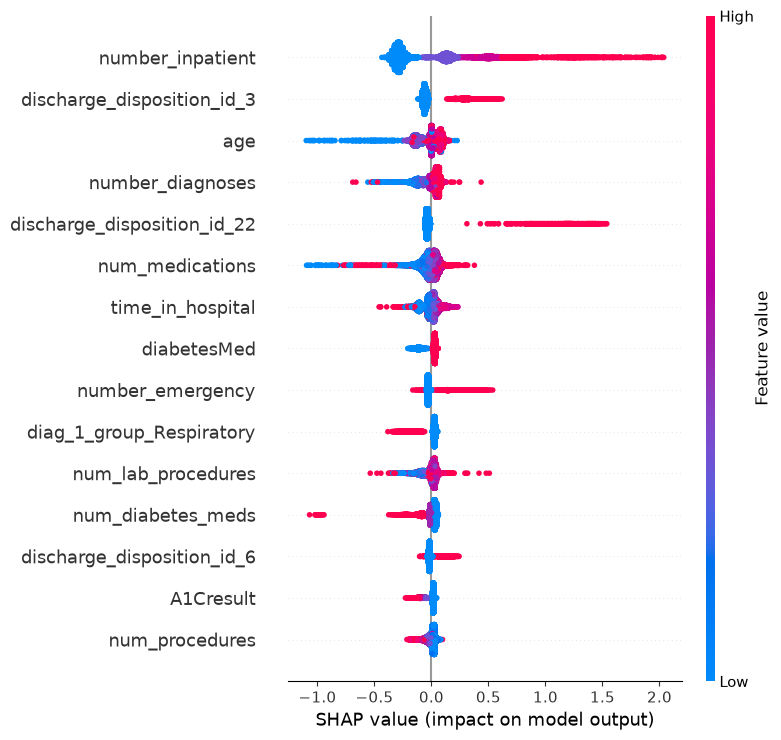

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_v2, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreting the summary plot

The model's top predictors are dominated by prior hospital utilization and encounter characteristics rather than lab results. `number_inpatient` (how many inpatient visits the patient had in the preceding year) stands out clearly as the single strongest predictor, well ahead of everything else, followed by discharge disposition, age, number of diagnoses, number of medications, and time in hospital.

This makes clinical sense. A patient with a recent history of inpatient admissions is plausibly a genuinely sicker or more complex patient overall, and that history is a strong signal on its own, arguably stronger than any single lab value from the current encounter.

`A1Cresult` itself ranks low in this global ranking, near the bottom of the top 15 features shown. On its own, that might look like it contradicts the paper's central finding that HbA1c measurement matters. It doesn't, but it does mean the story is more nuanced than "HbA1c is the most important feature," and that nuance is worth digging into directly rather than glossing over, which is what the next two sections do.

<Figure size 1000x800 with 0 Axes>

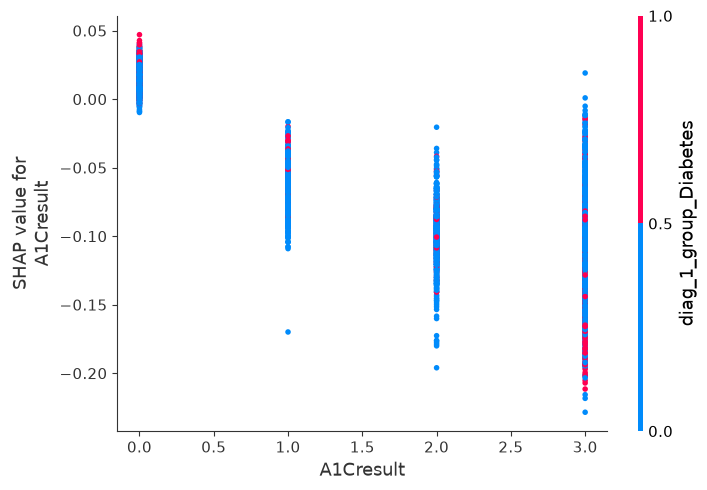

In [66]:
plt.figure(figsize=(10, 8))
shap.dependence_plot('A1Cresult', shap_values, X_test_v2, interaction_index='diag_1_group_Diabetes', show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_a1c_dependence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreting the A1Cresult dependence plot

While A1Cresult ranks low in overall importance, the dependence plot tells a more specific story than the summary plot alone. It shows a consistent direction: patients who had an HbA1c test (regardless of the result) tend to have a lower, more negative SHAP value, meaning the model associates testing with lower predicted readmission risk, while patients who weren't tested cluster closer to zero or slightly positive.

That's directionally consistent with the paper's central finding, testing is associated with lower readmission risk, even though the magnitude of that effect is small compared to features like prior utilization history. In other words, A1Cresult isn't the model's most powerful predictor, but the direction of its effect lines up with what the original paper reported.

The dependence plot is colored by `diag_1_group_Diabetes`, to check whether this effect is stronger specifically for patients whose primary diagnosis is diabetes itself, which is exactly what the paper's own interaction analysis found. A visual read on this is limited though, since diabetes-primary patients are a relatively small subgroup within the test set, making any color pattern hard to distinguish reliably by eye. The next section checks this more directly and reliably, using a straightforward grouped comparison rather than relying on visual interpretation of the SHAP plot.

## Direct Replication of the Paper's Core Finding

The SHAP dependence plot suggested HbA1c testing matters more for diabetes-primary patients, but a direct comparison is more reliable than reading it off a scatter plot. This is essentially the paper's central finding, restated as a straightforward question: does HbA1c testing show a bigger association with readmission for patients whose primary admitting diagnosis is diabetes, versus everyone else?

The comparison below splits the data into two groups (diabetes as the primary diagnosis, versus any other primary diagnosis) and looks at the readmission rate broken down by A1Cresult within each group.

In [67]:
diabetes_patients = df[df['diag_1_group'] == 'Diabetes']
other_patients = df[df['diag_1_group'] != 'Diabetes']

print("Diabetes as primary diagnosis:")
print(diabetes_patients.groupby('A1Cresult')['readmitted_binary'].agg(['mean', 'count']))

print("\nOther primary diagnosis:")
print(other_patients.groupby('A1Cresult')['readmitted_binary'].agg(['mean', 'count']))

Diabetes as primary diagnosis:
               mean  count
A1Cresult                 
0.0        0.147248   5922
1.0        0.117521    468
2.0        0.128378    296
3.0        0.086076   1975

Other primary diagnosis:
               mean  count
A1Cresult                 
0.0        0.114497  76587
1.0        0.095644   4454
2.0        0.099166   3479
3.0        0.103700   6162
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, subsample=0.6; total time=   5.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, subsample=0.6; total time=   5.1s
[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, subsample=1.0; total time=   6.9s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=500, subsample=0.6; total time=  11.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, min_child_weight

### Result: the paper's finding replicates

For patients with diabetes as their primary diagnosis, the readmission rate drops noticeably between those who weren't tested and those who were tested and had a high result, a meaningfully larger gap than for patients with any other primary diagnosis, where testing shows only a small difference in readmission rate.

This directly replicates the paper's central claim: HbA1c testing is associated with a bigger drop in readmission specifically for patients whose primary reason for admission is diabetes itself, and a much smaller effect for patients admitted primarily for something else, even if diabetes is a secondary diagnosis for them too.

Taken together with the SHAP analysis, this gives a fuller picture than either result alone. Prior hospital utilization is the dominant predictor in the model overall, but HbA1c testing has a real, targeted effect specifically for the subgroup the paper identified. That's a more precise and more defensible claim than either "HbA1c doesn't matter" (which the low global SHAP ranking alone might suggest) or "HbA1c is the most important factor" (which isn't supported by the data). The truth sits between those two, and being able to state that precisely, rather than reaching for the more dramatic headline in either direction, is the actual point of this analysis.